In [92]:
import numpy as np
import pyvista as pv
from scipy.spatial import KDTree
import sys
sys.path.append("..")
from error_func import error

case_name = "case1"
mesh_name = "coil_box"
solver1 = "ngsolve"
solver2 = "comsol"

sol_ngsolve = np.load(f"../../output/{case_name}/gauss/{case_name}_{solver1}.npy")
sol_comsol = np.genfromtxt(f"../../output/{case_name}/gauss/{case_name}_comsol.txt", delimiter = " ")

print(sol_ngsolve.shape)
print(sol_comsol.shape)

print(sol_ngsolve.shape)
print(sol_comsol.shape)


(69629, 7)
(10751, 7)
(69629, 7)
(10751, 7)


In [93]:
print("Min and max X coord:")
print(np.min(sol_ngsolve[:, 0:3]))
print(np.max(sol_ngsolve[:, 0:3]))

print("Min and max Y coord:")
print(np.min(sol_ngsolve[:, 0:3]))
print(np.max(sol_ngsolve[:, 0:3]))

print("Min and max Z coord:")
print(np.min(sol_ngsolve[:, 0:3]))
print(np.max(sol_ngsolve[:, 0:3]))

print("")

print("Min and max X coord:")
print(np.min(sol_comsol[:, 0:3]))
print(np.max(sol_comsol[:, 0:3]))

print("Min and max Y coord:")
print(np.min(sol_comsol[:, 0:3]))
print(np.max(sol_comsol[:, 0:3]))

print("Min and max Z coord:")
print(np.min(sol_comsol[:, 0:3]))
print(np.max(sol_comsol[:, 0:3]))

Min and max X coord:
-0.099551605255125
0.09795298646876001
Min and max Y coord:
-0.099551605255125
0.09795298646876001
Min and max Z coord:
-0.099551605255125
0.09795298646876001

Min and max X coord:
-0.09955160525513063
0.05438584320150776
Min and max Y coord:
-0.09955160525513063
0.05438584320150776
Min and max Z coord:
-0.09955160525513063
0.05438584320150776


In [94]:
tree = KDTree(sol_ngsolve[:, 0:3])
distances, indices = tree.query(sol_comsol[:, 0:3])

max_dist = np.max(distances)
print(f"Maximum alignment error (distance): {max_dist:.6e}")
if max_dist > 1e-4:
    print("Warning: Large distance detected. Are the geometries identical?")


sol_ngsolve_reordered = sol_ngsolve[indices, :]

np.save(f"../../output/{case_name}/gauss/{case_name}_{solver1}_reordered_to_{solver2}.npy", sol_ngsolve_reordered)

Maximum alignment error (distance): 1.269827e-13


In [95]:
sol_ngsolve = np.load(f"../../output/{case_name}/gauss/{case_name}_{solver1}_reordered_to_{solver2}.npy")
elec_pot_ngsolve = sol_ngsolve[:, 3]
curr_dens_ngsolve = sol_ngsolve[:, 4:7]

sol_comsol = np.genfromtxt(f"../../output/{case_name}/gauss/{case_name}_comsol.txt", delimiter = " ")
elec_pot_comsol = sol_comsol[:, 3]
curr_dens_comsol = sol_comsol[:, 4:7]

print(elec_pot_ngsolve.shape)
print(elec_pot_comsol.shape)
print(np.max(elec_pot_comsol))
print(np.max(elec_pot_ngsolve))

print(np.min(elec_pot_comsol))
print(np.min(elec_pot_ngsolve))

print("")

print(curr_dens_ngsolve.shape)
print(curr_dens_comsol.shape)
print(np.max(curr_dens_ngsolve))
print(np.max(curr_dens_comsol))
print(np.min(curr_dens_ngsolve))
print(np.min(curr_dens_comsol))

(10751,)
(10751,)
311729.90607509966
311736.85662603955
211.41117580948696
211.41117581157962

(10751, 3)
(10751, 3)
32770039.24039918
32770039.240536053
-32703522.9652724
-32703522.96526166


In [96]:
mesh = sol_comsol[:, 0:3].copy()

In [97]:
print(f"Coordinate errors between {solver1} and {solver2}:")

mesh = error(sol=sol_ngsolve[:, 0:3], sol_ref=sol_comsol[:, 0:3], 
             eps = 1e-12, mesh=mesh, tag="vector", save_tag=None)

Coordinate errors between ngsolve and comsol:

  * Max. absolute error in x direction  : 9.124e-14.
  * Avg. absolute error in x direction  : 2.608e-14.

  * Max. relative error in x direction : 1.403e-07 %.
  * Avg. relative error in x direction : 1.832e-10 %.

  * Max. absolute error in y direction  : 9.074e-14.
  * Avg. absolute error in y direction  : 2.821e-14.

  * Max. relative error in y direction : 9.850e-08 %.
  * Avg. relative error in y direction : 2.097e-10 %.

  * Max. absolute error in z direction  : 9.535e-14.
  * Avg. absolute error in z direction  : 2.510e-14.

  * Max. relative error in z direction : 4.411e-06 %.
  * Avg. relative error in z direction : 1.434e-09 %.


In [98]:
print(f"Current density errors between {solver1} and {solver2}:")

mesh = error(sol=curr_dens_ngsolve, sol_ref=curr_dens_comsol, 
             eps = 1e-6, mesh=mesh, tag="vector", save_tag=None, save_tag_array=True)

# print(curr_dens_ngsolve[2200, :])
# print(curr_dens_comsol[2200, :])

lim_x = (mesh[:, 3] > 10.0).sum()
lim_y = (mesh[:, 4] > 10.0).sum()
lim_z = (mesh[:, 5] > 10.0).sum()

print("")

print(f"Percent of values above 10% in x direction: {np.round(lim_x * 100 / mesh.shape[0], 2)}%")
print(f"Percent of values above 10% in y direction: {np.round(lim_y * 100 / mesh.shape[0], 2)}%")
print(f"Percent of values above 10% in z direction: {np.round(lim_z * 100 / mesh.shape[0], 2)}%")

J_x_err = mesh[:, 3]
J_y_err = mesh[:, 4]
J_z_err = mesh[:, 5]

J_x_err = np.extract(J_x_err<=10, J_x_err)
J_y_err = np.extract(J_y_err<=10, J_y_err)
J_z_err = np.extract(J_z_err<=10, J_z_err)


Current density errors between ngsolve and comsol:

  * Max. absolute error in x direction  : 1.283e+06.
  * Avg. absolute error in x direction  : 2.334e+03.

  * Max. relative error in x direction : 3.777e+13 %.
  * Avg. relative error in x direction : 1.101e+10 %.

  * Max. absolute error in y direction  : 8.444e+05.
  * Avg. absolute error in y direction  : 2.155e+03.

  * Max. relative error in y direction : 2.818e+00 %.
  * Avg. relative error in y direction : 7.288e-03 %.

  * Max. absolute error in z direction  : 1.264e+06.
  * Avg. absolute error in z direction  : 2.241e+03.

  * Max. relative error in z direction : 6.749e+13 %.
  * Avg. relative error in z direction : 2.716e+10 %.

Percent of values above 10% in x direction: 2.05%
Percent of values above 10% in y direction: 0.0%
Percent of values above 10% in z direction: 2.15%


/home/wiera/Documents/EM_simulation/scripts/case1/../error_func.py:62: RuntimeWarning: divide by zero encountered in divide
  rel_error_dir = np.where(denom > eps, num * 100 / denom, np.nan)
/home/wiera/Documents/EM_simulation/scripts/case1/../error_func.py:62: RuntimeWarning: invalid value encountered in divide
  rel_error_dir = np.where(denom > eps, num * 100 / denom, np.nan)


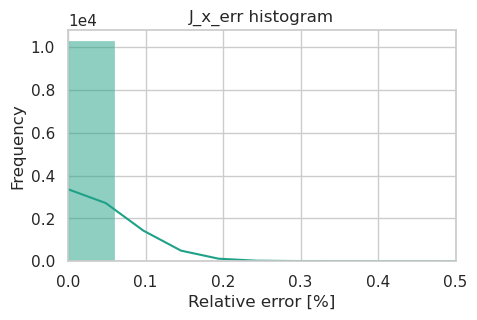

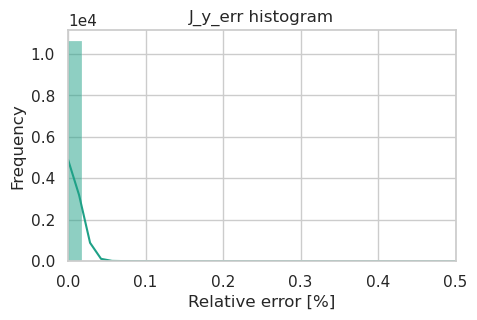

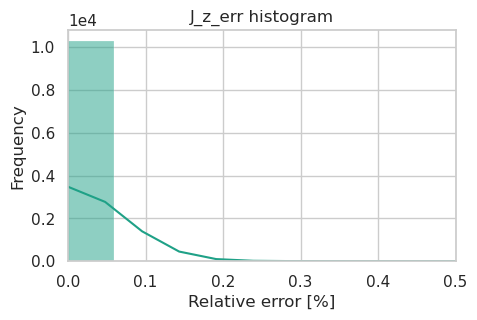

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid") 
palette = sns.color_palette("viridis") # You can use "rocket", "mako", or "flare"

fig, ax = plt.subplots(1, 1)
fig.set_figheight(3)
fig.set_figwidth(5)

sns.histplot(J_x_err, kde=True, color=palette[3], edgecolor="white", bins=160, ax=ax)

ax.set_title('J_x_err histogram', fontsize=12)
ax.set_xlabel('Relative error [%]', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

ax.set_xlim(0.0, 0.5)

plt.ticklabel_format(axis='both', style='sci', scilimits=(-2,2))

plt.show()


fig, ax = plt.subplots(1, 1)
fig.set_figheight(3)
fig.set_figwidth(5)

sns.histplot(J_y_err, kde=True, color=palette[3], edgecolor="white", bins=160, ax=ax)

ax.set_title('J_y_err histogram', fontsize=12)
ax.set_xlabel('Relative error [%]', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

ax.set_xlim(0.0, 0.5)

plt.ticklabel_format(axis='both', style='sci', scilimits=(-2,2))

plt.show()


fig, ax = plt.subplots(1, 1)
fig.set_figheight(3)
fig.set_figwidth(5)

sns.histplot(J_z_err, kde=True, color=palette[3], edgecolor="white", bins=160, ax=ax)

ax.set_title('J_z_err histogram', fontsize=12)
ax.set_xlabel('Relative error [%]', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

ax.set_xlim(0.0, 0.5)

plt.ticklabel_format(axis='both', style='sci', scilimits=(-2,2))

plt.show()

In [100]:
print(f"Electric potential errors between {solver1} and {solver2}:")

mesh = error(sol=elec_pot_ngsolve, sol_ref=elec_pot_comsol,
             eps = 1e-6, mesh=mesh, tag="scalar", save_tag=None)

Electric potential errors between ngsolve and comsol:

  * Max. absolute error : 2.073e+01.
  * Avg. absolute error : 4.069e-02.

  * Max. relative error : 6.656e-03 %.
  * Avg. relative error : 1.309e-05 %.


In [101]:
np.save(f"../../output/{case_name}/gauss/{case_name}_error_ngsolve_comsol.npy", mesh)
np.savetxt(f"../../output/{case_name}/gauss/{case_name}_error_ngsolve_comsol.txt", mesh, delimiter=',', header='x,y,z,J_x_err,J_y_err,J_z_err')